- 作者：东哥起飞

- 首发于[《100天风控专家》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky) 评分卡模型篇-模型校准/模型校准方法(1)：错误分配和Python实操

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import statsmodels as sts
import statsmodels.api as sm
import scorecardpy as sc
import warnings
import sklearn
import toad
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [28]:
# 本代码所涉及算包的版本
print('pandas:',pd.__version__)
print('numpy:',np.__version__)
print('sklearn:',sklearn.__version__)
print('scorecardpy:',sc.__version__)
print('statsmodels',sts.__version__)
print('toad',toad.__version__)

pandas: 2.0.0
numpy: 1.23.5
sklearn: 1.3.2
scorecardpy: 0.1.9.7
statsmodels 0.13.5
toad 0.1.3


## 0.样本抽样

In [29]:
df = pd.read_excel('huabei_model_v1.xlsx')
df.shape

(46000, 22)

In [30]:
df.head(1)

,sample_id,sample_month,have_car_prob_grade,have_fang_prob_grade,xfdc_index,mobile_fixed_grade,adr_stability_grade,occupation,tot_pay_amt_6m_grade,last_6m_avg_asset_total_grade,ovd_order_cnt_6m_grade,ovd_order_amt_6m_grade,positive_biz_cnt_1y_grade,risk_score,cust_seg,dev_stability_grade,ovd_order_days_6m_grade,first_loan_length_grade,repay_amt_6m_grade,repayment_ability_rank,riskrank,is_dlq_30d
0,11026,201804,2,1,2,5,7,专业技术人员（模型预测）,8,3,3,1,4,4,D,C,1,1,7,B,C,1


In [31]:
df['repayment_ability_rank'] = df['repayment_ability_rank'].map({'A':1,'B':2,'C':3,'D':4})
df['dev_stability_grade'] = df['dev_stability_grade'].map({'A':1,'B':2,'C':3,'D':4})
df['cust_seg'] = df['cust_seg'].map({'A':1,'B':2,'C':3,'D':4})
df['riskrank'] = df['riskrank'].map({'A':1,'B':2,'C':3,'D':4})

In [32]:
# 划分数据集
y_target = 'is_dlq_30d'
col = df.columns.difference(['sample_id','sample_month','occupation',y_target]).tolist()
y = df[y_target]
X = df[col]

In [33]:
pd.concat([
df['is_dlq_30d'].value_counts(),
df['is_dlq_30d'].value_counts(normalize=True)],axis=1)

,count,proportion
is_dlq_30d,,
0,45000,0.978261
1,1000,0.021739


In [34]:
# 样本不均衡，采取好客户抽样，坏客户不动
bad_indices = np.where(y == 1)[0]
good_indices = np.where(y == 0)[0]

n_bad = len(bad_indices)
good_to_bad = 9
np.random.seed(12)
undersampled_good_indices = np.random.choice(good_indices, size=int(good_to_bad*n_bad), replace=False)

# 抽样比例
undersampled_ratio = good_to_bad*n_bad/len(good_indices)
print('好客户抽样比例为：%s %%'%(undersampled_ratio*100))

undersampled_indices = np.concatenate([bad_indices, undersampled_good_indices])
X_undersampled = X.iloc[undersampled_indices]
y_undersampled = y.iloc[undersampled_indices]
df_sampled = pd.concat([X_undersampled,y_undersampled],axis=1)

好客户抽样比例为：20.0 %


In [35]:
pd.concat([
y_undersampled.value_counts(),
y_undersampled.value_counts(normalize=True)],axis=1)

,count,proportion
is_dlq_30d,,
0,9000,0.9
1,1000,0.1


## 1.建模

In [36]:
# 样本划分为训练集、测试集
train, test = train_test_split(
    df_sampled[col+[y_target]],
    test_size=0.2,
    random_state=42
)

# 训练接WOE转换计算
transformer = toad.transform.WOETransformer()
train_woe = transformer.fit_transform(
    train, 
    train[y_target],
    exclude=[y_target]
)
# 对测试集套用WOE
test_woe = transformer.transform(test)

# 使用sklearn拟合逻辑回归
lr = LogisticRegression()
lr.fit(train_woe[col], train[y_target])

# 训练集评估
train_pred = lr.predict_proba(train_woe[col])[:, 1]
train['train_prob'] = train_pred
print("\nTrain AUC:", toad.metrics.AUC(train_pred, train[y_target]))

# 测试集评估
test_pred = lr.predict_proba(test_woe[col])[:, 1]
test['test_pred'] = test_pred
print("Test AUC:", toad.metrics.AUC(test_pred, test[y_target]))


Train AUC: 0.9160265950290923
Test AUC: 0.9117498712225275


## 2. 错误分配（Missassignment）

ln(oddsr/oddse)

In [37]:
# 计算odds
oddsr = df['is_dlq_30d'].value_counts(normalize=True)[1]/df['is_dlq_30d'].value_counts(normalize=True)[0]
oddse = y_undersampled.value_counts(normalize=True)[1]/y_undersampled.value_counts(normalize=True)[0]
print('样本odds', round(oddse,2))
print('真实odds', round(oddsr,2))

样本odds 0.11
真实odds 0.02


In [38]:
# 校准函数（明确参数意义）
def missassignment(p_pred, odds1, odds2):
    """
    odds1: 抽样后的样本
    odds2: 抽样前的样本
    """
    C = np.log(p_pred/(1-p_pred)) + np.log(odds2/odds1)
    return np.exp(C) / (1 + np.exp(C))

# 错误分配校准
miss_test_probs = missassignment(test_pred, oddse, oddsr)
miss_train_probs = missassignment(train_pred, oddse, oddsr)
test['miss_test_probs'] = miss_test_probs
train['miss_train_probs'] = miss_train_probs

## 3. 权重还原（Weight）

In [39]:
# 校准函数（明确参数意义）
def weightback(p_pred, bad_sample_ratio=1.0, good_sample_ratio=undersampled_ratio):
    """
    bad_sample_ratio: 坏客户抽样比例（未抽样=1.0）
    good_sample_ratio: 好客户抽样比例
    """
    p_pred = np.clip(p_pred, 1e-15, 1-1e-15)
    return p_pred / (p_pred + (1-p_pred) * (bad_sample_ratio/good_sample_ratio))

# 权重还原校准
weight_test_probs = weightback(test_pred)
weight_train_probs = weightback(train_pred)

test['weight_test_probs'] = weight_test_probs
train['weight_train_probs'] = weight_train_probs

## 4. 结果对比

In [40]:
# 描述性统计
pd.concat([test['miss_test_probs'].describe(),
           test['weight_test_probs'].describe(),
           train['miss_train_probs'].describe(),
           train['weight_train_probs'].describe()],axis=1)

,miss_test_probs,weight_test_probs,miss_train_probs,weight_train_probs
count,2000.000000,2000.000000,8000.000000,8000.000000
mean,0.035540,0.035540,0.034347,0.034347
std,0.087892,0.087892,0.086165,0.086165
min,0.000155,0.000155,0.000141,0.000141
25%,0.001187,0.001187,0.001121,0.001121
50%,0.004252,0.004252,0.003758,0.003758
75%,0.024534,0.024534,0.020159,0.020159
max,0.667022,0.667022,0.685577,0.685577


In [41]:
prob_res = test[['test_pred','miss_test_probs','weight_test_probs']]
prob_res

,test_pred,miss_test_probs,weight_test_probs
25294,0.027725,0.005671,0.005671
20959,0.002742,0.000550,0.000550
7787,0.002239,0.000449,0.000449
27214,0.001412,0.000283,0.000283
36451,0.008598,0.001732,0.001732
...,...,...,...
9170,0.030660,0.006286,0.006286
33207,0.079968,0.017087,0.017087
25844,0.075285,0.016022,0.016022
21095,0.003031,0.000608,0.000608


## 5. 校准曲线（Calibration Curve）

In [44]:
train_original, test_original = train_test_split(
    df[col+[y_target]],
    test_size=0.2,
    random_state=42
)
test_original_woe = transformer.transform(test_original)

test_original_woe_pred = lr.predict_proba(test_original_woe[col])[:, 1]
calibrated_test_original_probs = missassignment(test_original_woe_pred,oddse, oddsr)

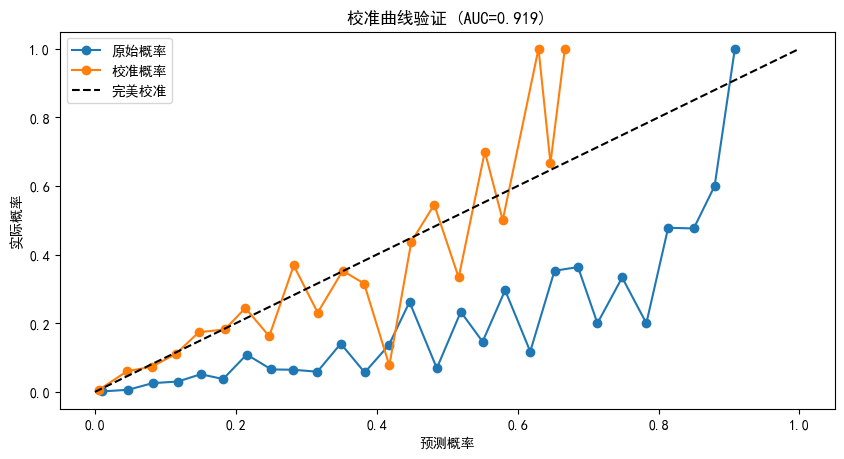

In [45]:
# 校准曲线（Calibration Curve）
def calibration_curve(probs, y_true, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(probs, bin_edges) - 1
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    bin_probs = []
    bin_actual = []
    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum() > 0:
            bin_probs.append(probs[mask].mean())
            bin_actual.append(y_true[mask].mean())
    
    return bin_probs, bin_actual

# 等频分箱校准曲线
plt.figure(figsize=(10, 5),dpi=100)
for name, probs in [('原始概率', test_original_woe_pred), ('校准概率', calibrated_test_original_probs)]:
    pred, actual = calibration_curve(probs, test_original[y_target], n_bins=30)
    plt.plot(pred, actual, 'o-', label=name)

plt.plot([0, 1], [0, 1], 'k--', label='完美校准')
plt.xlabel("预测概率")
plt.ylabel("实际概率")
plt.title(f"校准曲线验证 (AUC={roc_auc_score(test_original[y_target], test_original_woe_pred):.3f})")
plt.legend()
plt.show()

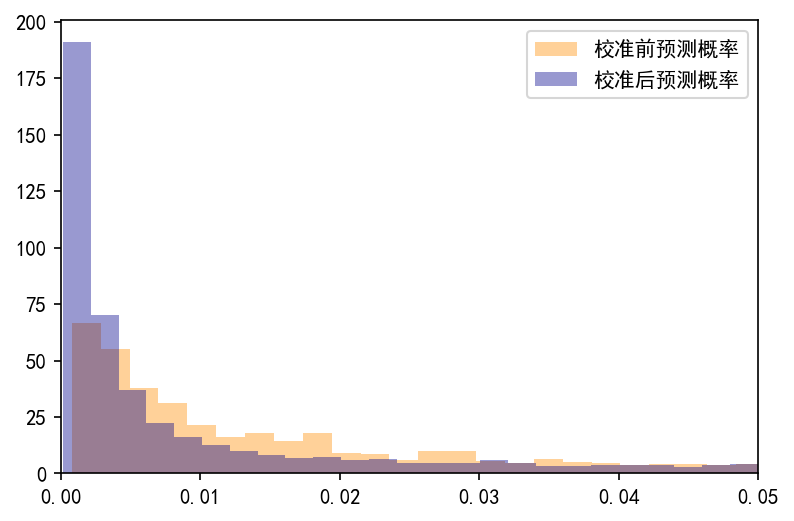

In [46]:
fig = plt.figure(dpi=150)
plt.hist(prob_res.loc[prob_res['miss_test_probs']<0.05,'test_pred'],  bins=100, alpha=0.4, color='darkorange', density=True, label='校准前预测概率')
plt.hist(prob_res.loc[prob_res['miss_test_probs']<0.20,'miss_test_probs'], bins=100, alpha=0.4, color='darkblue', density=True, label='校准后预测概率')
plt.xlim(0,0.05)
plt.legend(['校准前预测概率', '校准后预测概率'])
plt.show()

## 番外

如果对pandas不熟悉想要进阶的朋友可以了解下东哥的这个原创笔记，已经完全体，后续随着版本迭代会持续更新。

[《pandas进阶宝典》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)永久访问权限，500页图文笔记，近30万字，配套完整代码支持下载。

5大核心图文，具体包括：
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

感兴趣可以扫码了解，或者加我微信可以有折扣，加V：`Petery_1966`

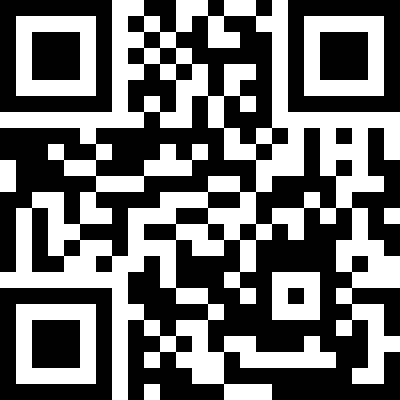